# Validation-Volume Mask and Orientation Forensics

This notebook investigates why the five-epoch baseline behaved very differently
across validation patients—especially volumes 104 and 116—before any longer
training is authorized.

It audits processed image/liver/tumor alignment, tumor containment inside the
liver, centroid geometry, orientation normalization, source-volume metadata,
patient-level model performance, and dense longitudinal overlays.

**Decision rule:** continue model development only if the processed masks are
geometrically credible. Otherwise stop and correct the dataset build.

## tl;dr

Run all cells with the project `.venv` kernel. This is a read-only dataset audit:

- the test split stays locked;
- no model training occurs;
- no dataset file is modified;
- validation tumor-positive slices are exhaustively inspected;
- a deterministic training reference sample is inspected for comparison;
- all tables, figures, contact sheets, and the final decision are saved.

The visual-review section is essential. Automated containment can detect mask
disagreement, but it cannot by itself prove that an anatomically contained
tumor annotation is clinically correct.

## Context & Methods

### Key assumptions

- LiTS label 1 is liver and label 2 is tumor; the derived binary organ mask
  should therefore contain the tumor mask apart from negligible resize edges.
- Image, organ mask, and tumor mask must have identical 256×256 geometry.
- The corrected manifest and frozen hash remain the source of truth.
- Validation volumes 104–116 must remain separate from training.
- Test volumes are not opened.

### Automated geometry gate

- volume-level tumor containment ≥ 99%;
- worst tumor-positive slice containment ≥ 95%;
- no shape, binary-mask, pixel-count, or path failures;
- source volume and segmentation references remain paired by volume.

Passing this gate still requires visual review of the generated contact sheets.

In [1]:
from __future__ import annotations

from pathlib import Path
from IPython.display import display
import hashlib
import json
import math
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_ROOT = Path(r"D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver")
DATASET_ROOT = Path(
    r"D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging"
    r"\build_corrected_20260713_214847_v2"
)
MANIFEST_PATH = DATASET_ROOT / "manifests" / "slice_manifest.csv"
BASELINE_OUTPUT_DIR = PROJECT_ROOT / "Practice" / "manifest_baseline_smoke_outputs"
BASELINE_PER_SLICE_PATH = BASELINE_OUTPUT_DIR / "baseline_smoke_per_slice.csv"
OUTPUT_DIR = PROJECT_ROOT / "Practice" / "validation_volume_forensics_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

SEED = 42
EXPECTED_MANIFEST_SHA256 = (
    "575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63c1bfc6c2c615861889"
)
FOCUS_VOLUMES = [104, 107, 108, 116]
TRAIN_REFERENCE_SLICES = 1_200
CONTACT_SHEET_SLICES = 12
VOLUME_CONTAINMENT_GATE = 0.99
SLICE_CONTAINMENT_GATE = 0.95

random.seed(SEED)
np.random.seed(SEED)

print(f"Manifest: {MANIFEST_PATH}")
print(f"Baseline predictions: {BASELINE_PER_SLICE_PATH}")
print(f"Outputs: {OUTPUT_DIR}")

Manifest: D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\02_staging\build_corrected_20260713_214847_v2\manifests\slice_manifest.csv
Baseline predictions: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\manifest_baseline_smoke_outputs\baseline_smoke_per_slice.csv
Outputs: D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\Practice\validation_volume_forensics_outputs


## Data

### 1. Verify manifest identity, source pairing, and test lock

In [2]:
from src.framework.data.manifest_dataset import VerifiedManifestDataset


def sha256_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


observed_manifest_hash = sha256_file(MANIFEST_PATH)
assert observed_manifest_hash == EXPECTED_MANIFEST_SHA256
manifest = pd.read_csv(MANIFEST_PATH)
assert len(manifest) == 58_638
assert manifest["sample_id"].is_unique
assert manifest["verification_status"].eq("verified").all()
assert manifest["manual_spatial_status"].eq("approved").all()

try:
    VerifiedManifestDataset(MANIFEST_PATH, split="test", root_dir=DATASET_ROOT)
except PermissionError as exc:
    print(f"PASS: test split remains locked: {exc}")
else:
    raise AssertionError("Test split opened without explicit authorization.")

source_pairs = (
    manifest.groupby("volume_id")
    .agg(
        volume_paths=("source_volume_path", "nunique"),
        segmentation_paths=("source_segmentation_path", "nunique"),
        volume_hashes=("source_volume_sha256", "nunique"),
        segmentation_hashes=("source_segmentation_sha256", "nunique"),
        transforms=("transform_applied", "nunique"),
        split=("split", "first"),
    )
    .reset_index()
)
assert source_pairs[
    ["volume_paths", "segmentation_paths", "volume_hashes", "segmentation_hashes", "transforms"]
].eq(1).all().all()

split_orientation = (
    manifest[["volume_id", "split", "transform_applied"]]
    .drop_duplicates()
    .groupby(["split", "transform_applied"])
    .size()
    .rename("volumes")
    .reset_index()
)
display(split_orientation)
print(f"PASS: manifest {observed_manifest_hash[:12]}... and source pairing verified.")

PASS: test split remains locked: Test data access is locked. Pass allow_test=True only for the one-time held-out evaluation after model decisions are frozen.


,split,transform_applied,volumes
0,test,rot180,14
1,train,identity,84
2,train,rot180,20
3,val,rot180,13


PASS: manifest 575a6fc391d6... and source pairing verified.


### 2. Load masks and compute slice geometry

Every validation tumor-positive slice is audited. The training comparison is a deterministic, lesion-size-stratified reference sample.

In [3]:
def resolve_path(value: str) -> Path:
    normalized = str(value).replace("\\", "/")
    path = Path(normalized)
    return path if path.is_absolute() else DATASET_ROOT / path


def load_binary(path: Path) -> np.ndarray:
    with Image.open(path) as handle:
        array = np.asarray(handle.convert("L"), dtype=np.uint8)
    return array > 0


def centroid(mask: np.ndarray) -> tuple[float, float]:
    rows, cols = np.nonzero(mask)
    if len(rows) == 0:
        return np.nan, np.nan
    return float(cols.mean()), float(rows.mean())


def bounding_box(mask: np.ndarray) -> tuple[float, float, float, float]:
    rows, cols = np.nonzero(mask)
    if len(rows) == 0:
        return (np.nan,) * 4
    return float(cols.min()), float(rows.min()), float(cols.max()), float(rows.max())


def audit_rows(frame: pd.DataFrame, cohort: str) -> pd.DataFrame:
    records = []
    for row in frame.itertuples(index=False):
        image_path = resolve_path(row.image_path)
        organ_path = resolve_path(row.organ_mask_path)
        tumor_path = resolve_path(row.tumor_mask_path)
        with Image.open(image_path) as handle:
            image_shape = np.asarray(handle.convert("L")).shape
        organ = load_binary(organ_path)
        tumor = load_binary(tumor_path)
        assert image_shape == organ.shape == tumor.shape == (256, 256), row.sample_id
        organ_px = int(organ.sum())
        tumor_px = int(tumor.sum())
        assert organ_px == int(row.organ_pixels), row.sample_id
        assert tumor_px == int(row.tumor_pixels), row.sample_id
        outside = tumor & ~organ
        inside_px = int((tumor & organ).sum())
        outside_px = int(outside.sum())
        containment = inside_px / max(tumor_px, 1)
        tumor_x, tumor_y = centroid(tumor)
        liver_x, liver_y = centroid(organ)
        x0, y0, x1, y1 = bounding_box(tumor)
        records.append({
            "cohort": cohort,
            "sample_id": row.sample_id,
            "volume_id": int(row.volume_id),
            "slice_index": int(row.slice_index),
            "transform_applied": row.transform_applied,
            "organ_pixels": organ_px,
            "tumor_pixels": tumor_px,
            "tumor_inside_liver_pixels": inside_px,
            "tumor_outside_liver_pixels": outside_px,
            "tumor_containment": containment,
            "tumor_centroid_x": tumor_x,
            "tumor_centroid_y": tumor_y,
            "liver_centroid_x": liver_x,
            "liver_centroid_y": liver_y,
            "centroid_distance": float(np.hypot(tumor_x - liver_x, tumor_y - liver_y)),
            "tumor_bbox_x0": x0, "tumor_bbox_y0": y0,
            "tumor_bbox_x1": x1, "tumor_bbox_y1": y1,
        })
    return pd.DataFrame(records)


val_positive = manifest.loc[
    manifest["split"].eq("val") & manifest["tumor_pixels"].gt(0)
].copy()

train_positive = manifest.loc[
    manifest["split"].eq("train") & manifest["tumor_pixels"].gt(0)
].copy()
train_positive["size_bin"] = pd.qcut(
    train_positive["tumor_pixels"], q=4, labels=False, duplicates="drop"
)
reference_parts = []
per_bin = TRAIN_REFERENCE_SLICES // train_positive["size_bin"].nunique()
for size_bin, group in train_positive.groupby("size_bin"):
    reference_parts.append(
        group.sample(n=min(per_bin, len(group)), random_state=SEED + int(size_bin))
    )
train_reference = pd.concat(reference_parts).head(TRAIN_REFERENCE_SLICES)

validation_audit = audit_rows(val_positive, "validation")
training_audit = audit_rows(train_reference, "train_reference")
geometry_audit = pd.concat([training_audit, validation_audit], ignore_index=True)
validation_audit.to_csv(OUTPUT_DIR / "validation_slice_geometry_audit.csv", index=False)
training_audit.to_csv(OUTPUT_DIR / "training_reference_geometry_audit.csv", index=False)

print(f"Audited {len(validation_audit):,} validation tumor-positive slices.")
print(f"Audited {len(training_audit):,} stratified training reference slices.")

Audited 1,042 validation tumor-positive slices.
Audited 1,200 stratified training reference slices.


## Results

### 3. Summarize containment and pixel parity by validation volume

In [4]:
volume_geometry = (
    validation_audit.groupby("volume_id")
    .agg(
        tumor_positive_slices=("sample_id", "size"),
        tumor_pixels=("tumor_pixels", "sum"),
        outside_pixels=("tumor_outside_liver_pixels", "sum"),
        mean_containment=("tumor_containment", "mean"),
        minimum_slice_containment=("tumor_containment", "min"),
        slices_below_99pct=("tumor_containment", lambda x: int((x < 0.99).sum())),
        mean_centroid_distance=("centroid_distance", "mean"),
        median_liver_centroid_x=("liver_centroid_x", "median"),
    )
    .reset_index()
)
volume_geometry["volume_containment"] = (
    1 - volume_geometry["outside_pixels"] / volume_geometry["tumor_pixels"]
)

if BASELINE_PER_SLICE_PATH.is_file():
    baseline_rows = pd.read_csv(BASELINE_PER_SLICE_PATH)
    baseline_positive = baseline_rows.loc[baseline_rows["true_pixels"].gt(0)]
    performance = (
        baseline_positive.groupby("volume_id")
        .agg(
            model_intersection=("intersection_pixels", "sum"),
            model_predicted=("predicted_pixels", "sum"),
            model_true=("true_pixels", "sum"),
            model_macro_dice=("dice", "mean"),
            model_detected_pct=("intersection_pixels", lambda x: 100 * (x > 0).mean()),
            model_predicted_empty_pct=("predicted_pixels", lambda x: 100 * (x == 0).mean()),
        )
        .reset_index()
    )
    performance["model_micro_dice"] = (
        2 * performance["model_intersection"]
        / (performance["model_predicted"] + performance["model_true"]).replace(0, np.nan)
    )
    volume_geometry = volume_geometry.merge(performance, on="volume_id", how="left")

volume_geometry.to_csv(OUTPUT_DIR / "validation_volume_geometry_summary.csv", index=False)
display(volume_geometry.style.format({
    "volume_containment": "{:.5f}",
    "mean_containment": "{:.5f}",
    "minimum_slice_containment": "{:.5f}",
    "mean_centroid_distance": "{:.1f}",
    "model_micro_dice": "{:.4f}",
    "model_macro_dice": "{:.4f}",
    "model_detected_pct": "{:.1f}%",
    "model_predicted_empty_pct": "{:.1f}%",
}))

,volume_id,tumor_positive_slices,tumor_pixels,outside_pixels,mean_containment,minimum_slice_containment,slices_below_99pct,mean_centroid_distance,median_liver_centroid_x,volume_containment,model_intersection,model_predicted,model_true,model_macro_dice,model_detected_pct,model_predicted_empty_pct,model_micro_dice
0,104,122,69032,0,1.00000,1.00000,0,22.8,155.557025,1.00000,458,1287,69032,0.0358,11.5%,46.7%,0.0130
1,107,71,1473,0,1.00000,1.00000,0,28.3,155.040195,1.00000,160,877,1473,0.1155,25.4%,40.8%,0.1362
2,108,202,363698,0,1.00000,1.00000,0,5.6,135.472216,1.00000,192926,208261,363698,0.5713,87.6%,8.9%,0.6746
3,109,131,18200,0,1.00000,1.00000,0,30.5,165.691921,1.00000,3140,8405,18200,0.2791,77.9%,9.2%,0.2360
4,110,130,31120,0,1.00000,1.00000,0,26.0,120.247147,1.00000,9108,10007,31120,0.3448,75.4%,21.5%,0.4429
5,111,92,1830,0,1.00000,1.00000,0,35.3,141.044559,1.00000,945,2039,1830,0.3334,55.4%,28.3%,0.4885
6,112,26,295,0,1.00000,1.00000,0,37.3,145.018633,1.00000,187,322,295,0.4270,61.5%,19.2%,0.6062
7,113,135,21076,0,1.00000,1.00000,0,13.5,141.567362,1.00000,11677,21984,21076,0.3704,76.3%,11.1%,0.5424
8,116,133,152763,0,1.00000,1.00000,0,34.7,147.027295,1.00000,17,479,152763,0.0001,3.8%,74.4%,0.0002


### 4. Plot containment, patient performance, and longitudinal mask burden

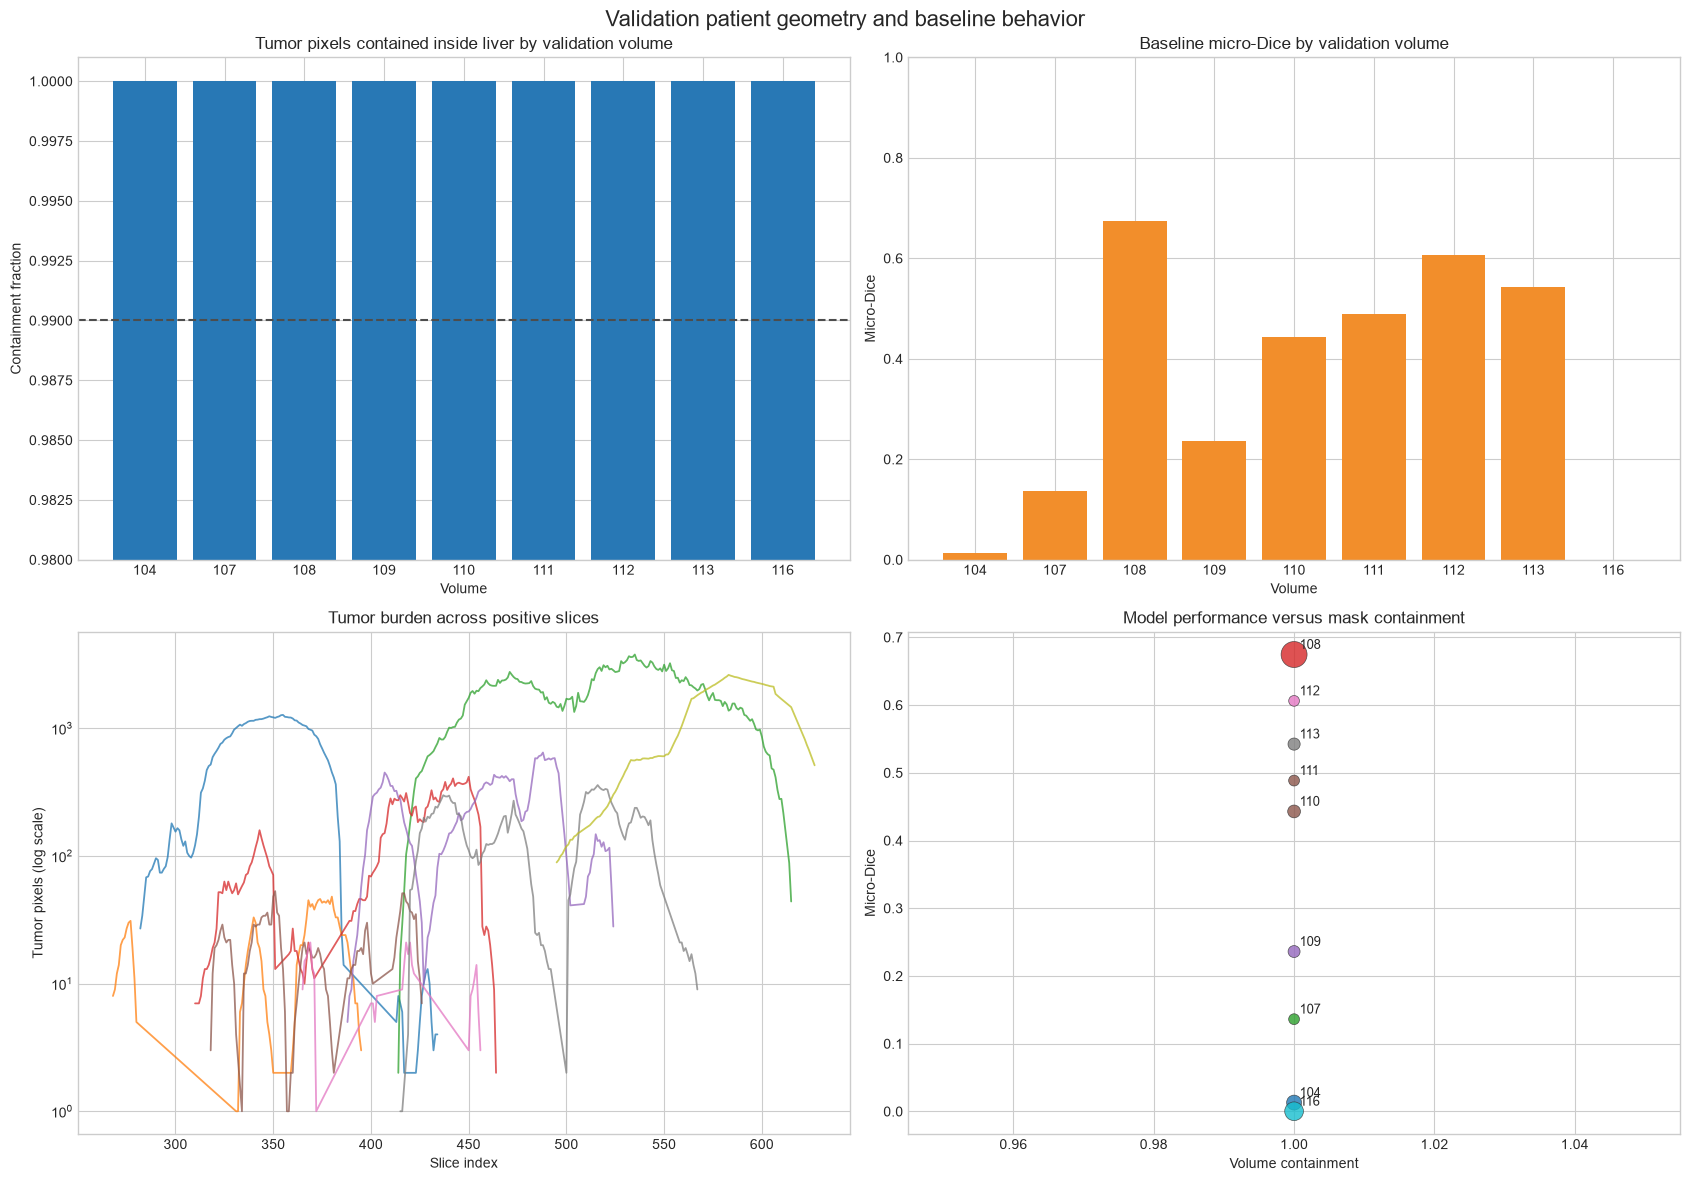

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(17, 12))

axes[0, 0].bar(
    volume_geometry["volume_id"].astype(str),
    volume_geometry["volume_containment"], color="#2878B5",
)
axes[0, 0].axhline(VOLUME_CONTAINMENT_GATE, linestyle="--", color="#4D4D4D")
axes[0, 0].set_ylim(max(0.9, volume_geometry["volume_containment"].min() - 0.02), 1.001)
axes[0, 0].set_title("Tumor pixels contained inside liver by validation volume")
axes[0, 0].set_xlabel("Volume"); axes[0, 0].set_ylabel("Containment fraction")

if "model_micro_dice" in volume_geometry:
    axes[0, 1].bar(
        volume_geometry["volume_id"].astype(str),
        volume_geometry["model_micro_dice"], color="#F28E2B",
    )
    axes[0, 1].set_ylim(0, 1)
    axes[0, 1].set_title("Baseline micro-Dice by validation volume")
    axes[0, 1].set_xlabel("Volume"); axes[0, 1].set_ylabel("Micro-Dice")

for volume_id, group in validation_audit.groupby("volume_id"):
    axes[1, 0].plot(
        group["slice_index"], group["tumor_pixels"],
        alpha=0.75, linewidth=1.3, label=str(volume_id),
    )
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Tumor burden across positive slices")
axes[1, 0].set_xlabel("Slice index"); axes[1, 0].set_ylabel("Tumor pixels (log scale)")

if "model_micro_dice" in volume_geometry:
    sizes = 60 + 290 * (
        volume_geometry["tumor_pixels"] / volume_geometry["tumor_pixels"].max()
    )
    axes[1, 1].scatter(
        volume_geometry["volume_containment"],
        volume_geometry["model_micro_dice"],
        s=sizes, c=volume_geometry["volume_id"], cmap="tab10",
        alpha=0.8, edgecolor="#333333", linewidth=0.5,
    )
    for row in volume_geometry.itertuples(index=False):
        axes[1, 1].annotate(
            str(row.volume_id), (row.volume_containment, row.model_micro_dice),
            xytext=(4, 4), textcoords="offset points", fontsize=9,
        )
    axes[1, 1].set_title("Model performance versus mask containment")
    axes[1, 1].set_xlabel("Volume containment"); axes[1, 1].set_ylabel("Micro-Dice")

fig.suptitle("Validation patient geometry and baseline behavior", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "validation_volume_geometry_and_performance.png", dpi=160, bbox_inches="tight")
plt.show()

### 5. Compare training and validation spatial geometry

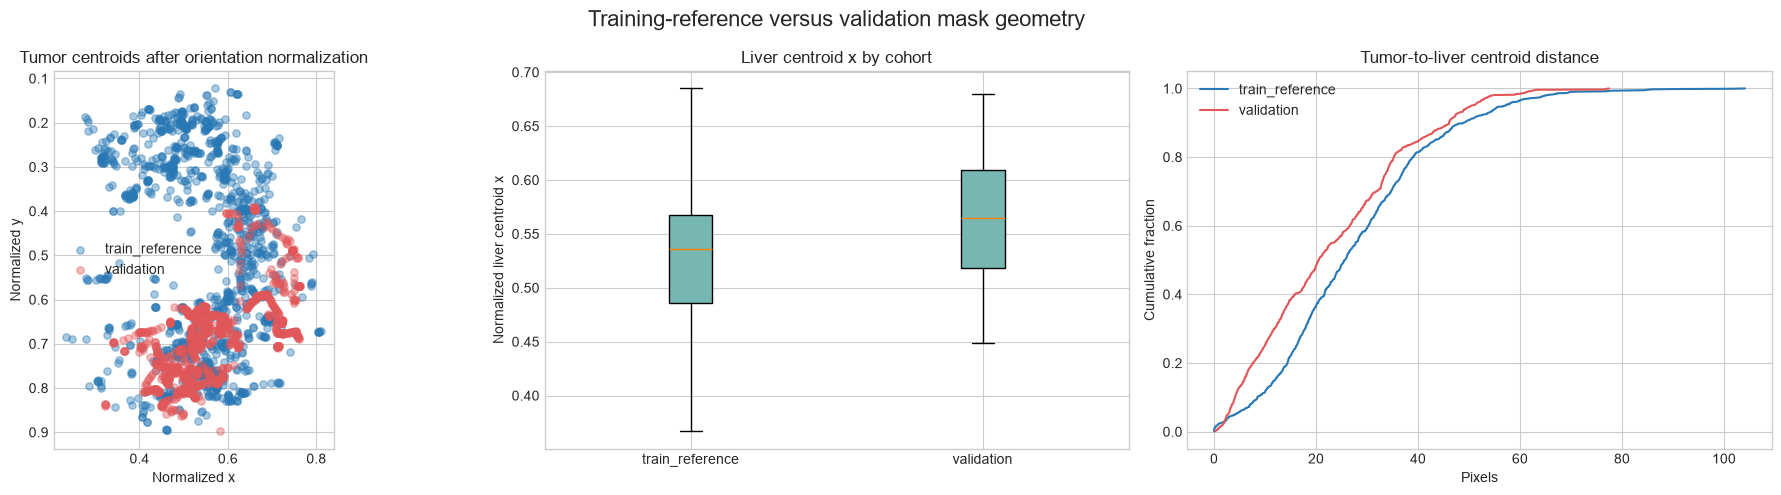

,cohort,slices,containment,median_tumor_x,median_tumor_y,median_liver_x,median_centroid_distance
0,train_reference,1200,1.0,0.552084,0.484262,0.535757,25.640005
1,validation,1042,1.0,0.541350,0.676772,0.565111,20.540155


In [6]:
comparison = geometry_audit.copy()
comparison["normalized_tumor_x"] = comparison["tumor_centroid_x"] / 255
comparison["normalized_tumor_y"] = comparison["tumor_centroid_y"] / 255
comparison["normalized_liver_x"] = comparison["liver_centroid_x"] / 255
comparison["normalized_liver_y"] = comparison["liver_centroid_y"] / 255

fig, axes = plt.subplots(1, 3, figsize=(19, 5))
cohort_colors = {"train_reference": "#2878B5", "validation": "#E15759"}
for cohort, group in comparison.groupby("cohort"):
    axes[0].scatter(
        group["normalized_tumor_x"], group["normalized_tumor_y"],
        alpha=0.4, s=28, label=cohort, color=cohort_colors[cohort],
    )
axes[0].legend()
axes[0].invert_yaxis()
axes[0].set_aspect("equal", adjustable="box")
axes[0].set_title("Tumor centroids after orientation normalization")
axes[0].set_xlabel("Normalized x"); axes[0].set_ylabel("Normalized y")

cohort_order = ["train_reference", "validation"]
axes[1].boxplot(
    [
        comparison.loc[comparison["cohort"].eq(cohort), "normalized_liver_x"].dropna()
        for cohort in cohort_order
    ],
    tick_labels=cohort_order, showfliers=False, patch_artist=True,
    boxprops={"facecolor": "#76B7B2"},
)
axes[1].set_title("Liver centroid x by cohort")
axes[1].set_xlabel(""); axes[1].set_ylabel("Normalized liver centroid x")

for cohort, group in comparison.groupby("cohort"):
    values = np.sort(group["centroid_distance"].dropna().to_numpy())
    axes[2].plot(
        values, np.arange(1, len(values) + 1) / len(values),
        label=cohort, color=cohort_colors[cohort],
    )
axes[2].legend()
axes[2].set_title("Tumor-to-liver centroid distance")
axes[2].set_xlabel("Pixels"); axes[2].set_ylabel("Cumulative fraction")

fig.suptitle("Training-reference versus validation mask geometry", fontsize=16)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "train_validation_geometry_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

cohort_summary = (
    comparison.groupby("cohort")
    .agg(
        slices=("sample_id", "size"),
        containment=("tumor_containment", "mean"),
        median_tumor_x=("normalized_tumor_x", "median"),
        median_tumor_y=("normalized_tumor_y", "median"),
        median_liver_x=("normalized_liver_x", "median"),
        median_centroid_distance=("centroid_distance", "median"),
    )
    .reset_index()
)
display(cohort_summary)

### 6. Create dense longitudinal contact sheets for focus volumes

Green shows tumor inside the liver, blue shows tumor outside the liver, and the yellow contour is the liver boundary.

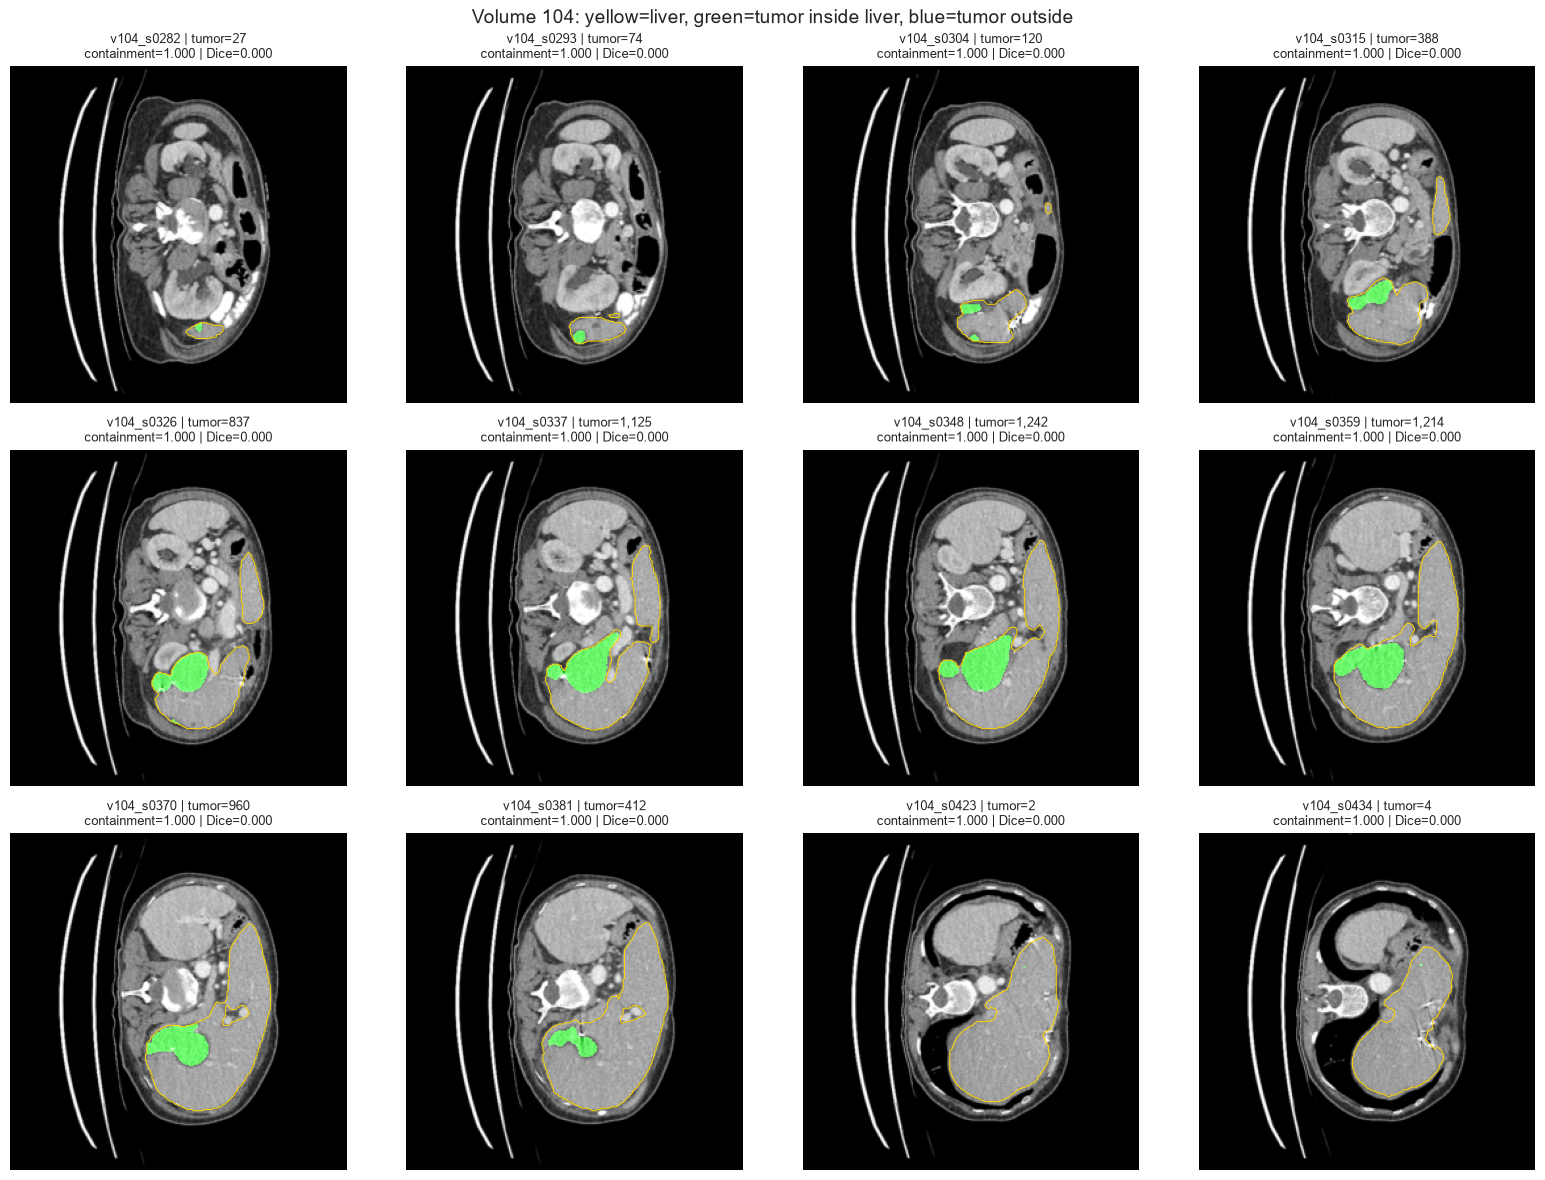

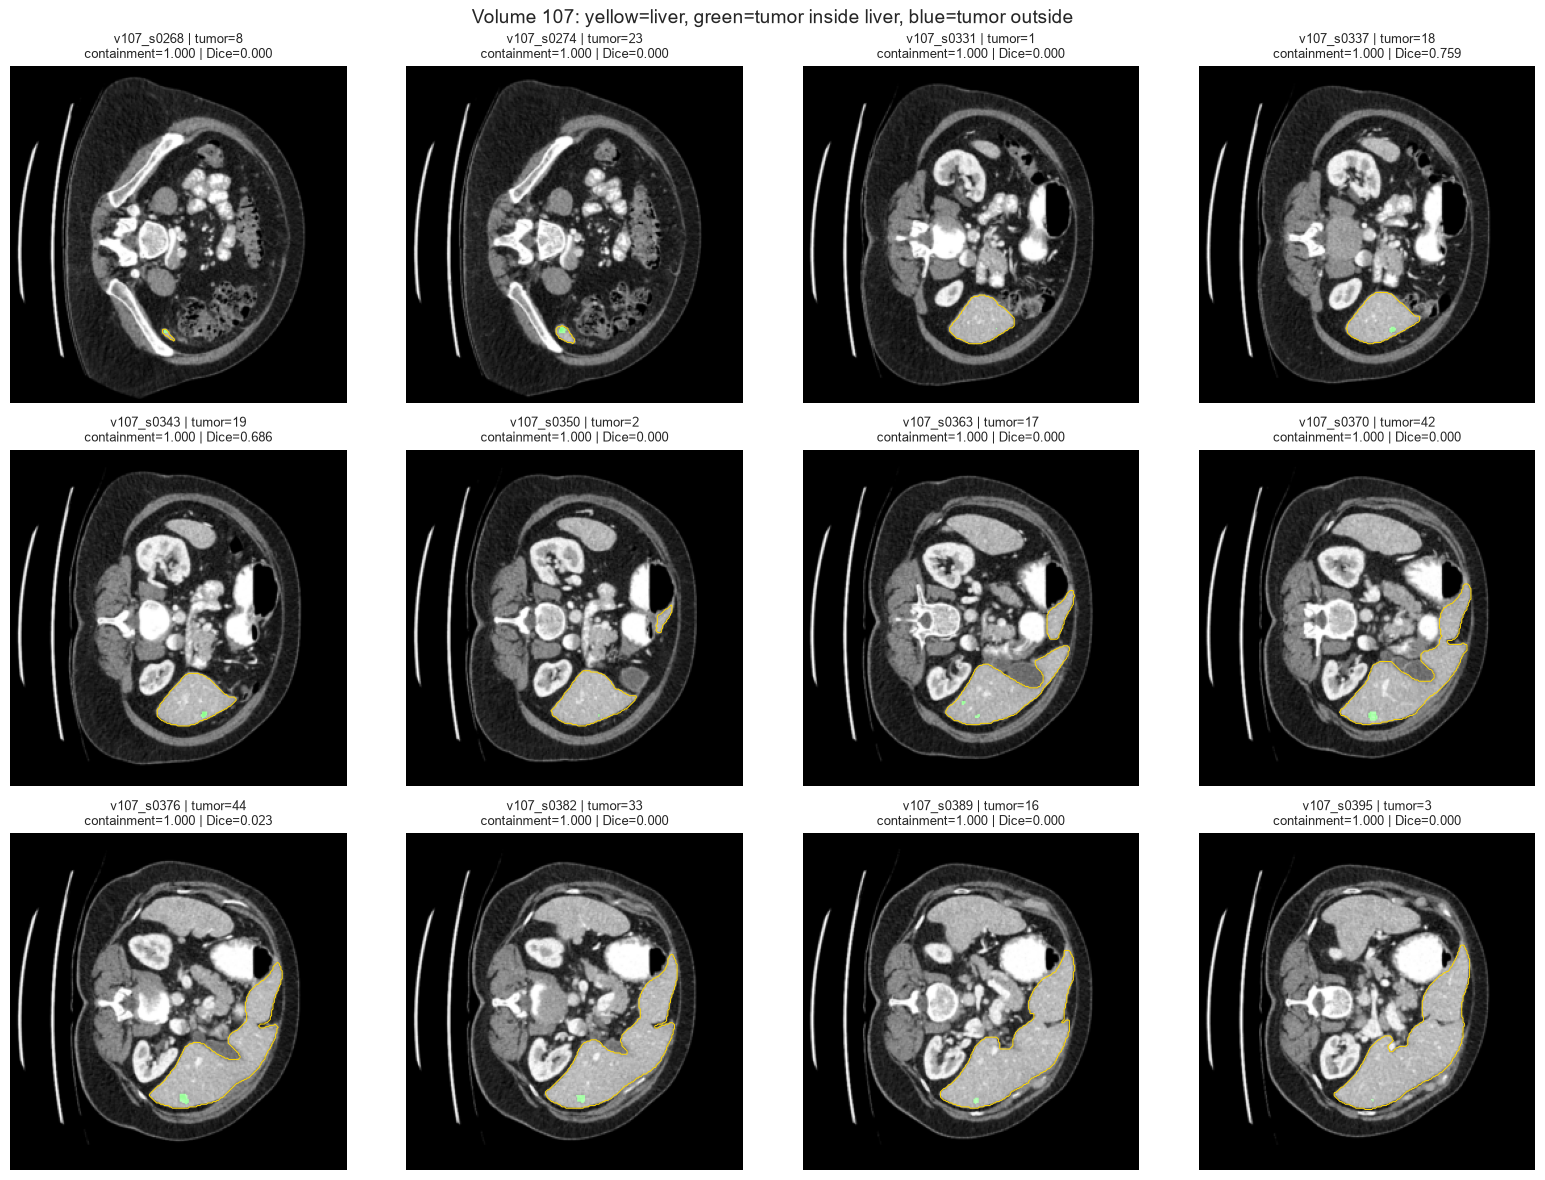

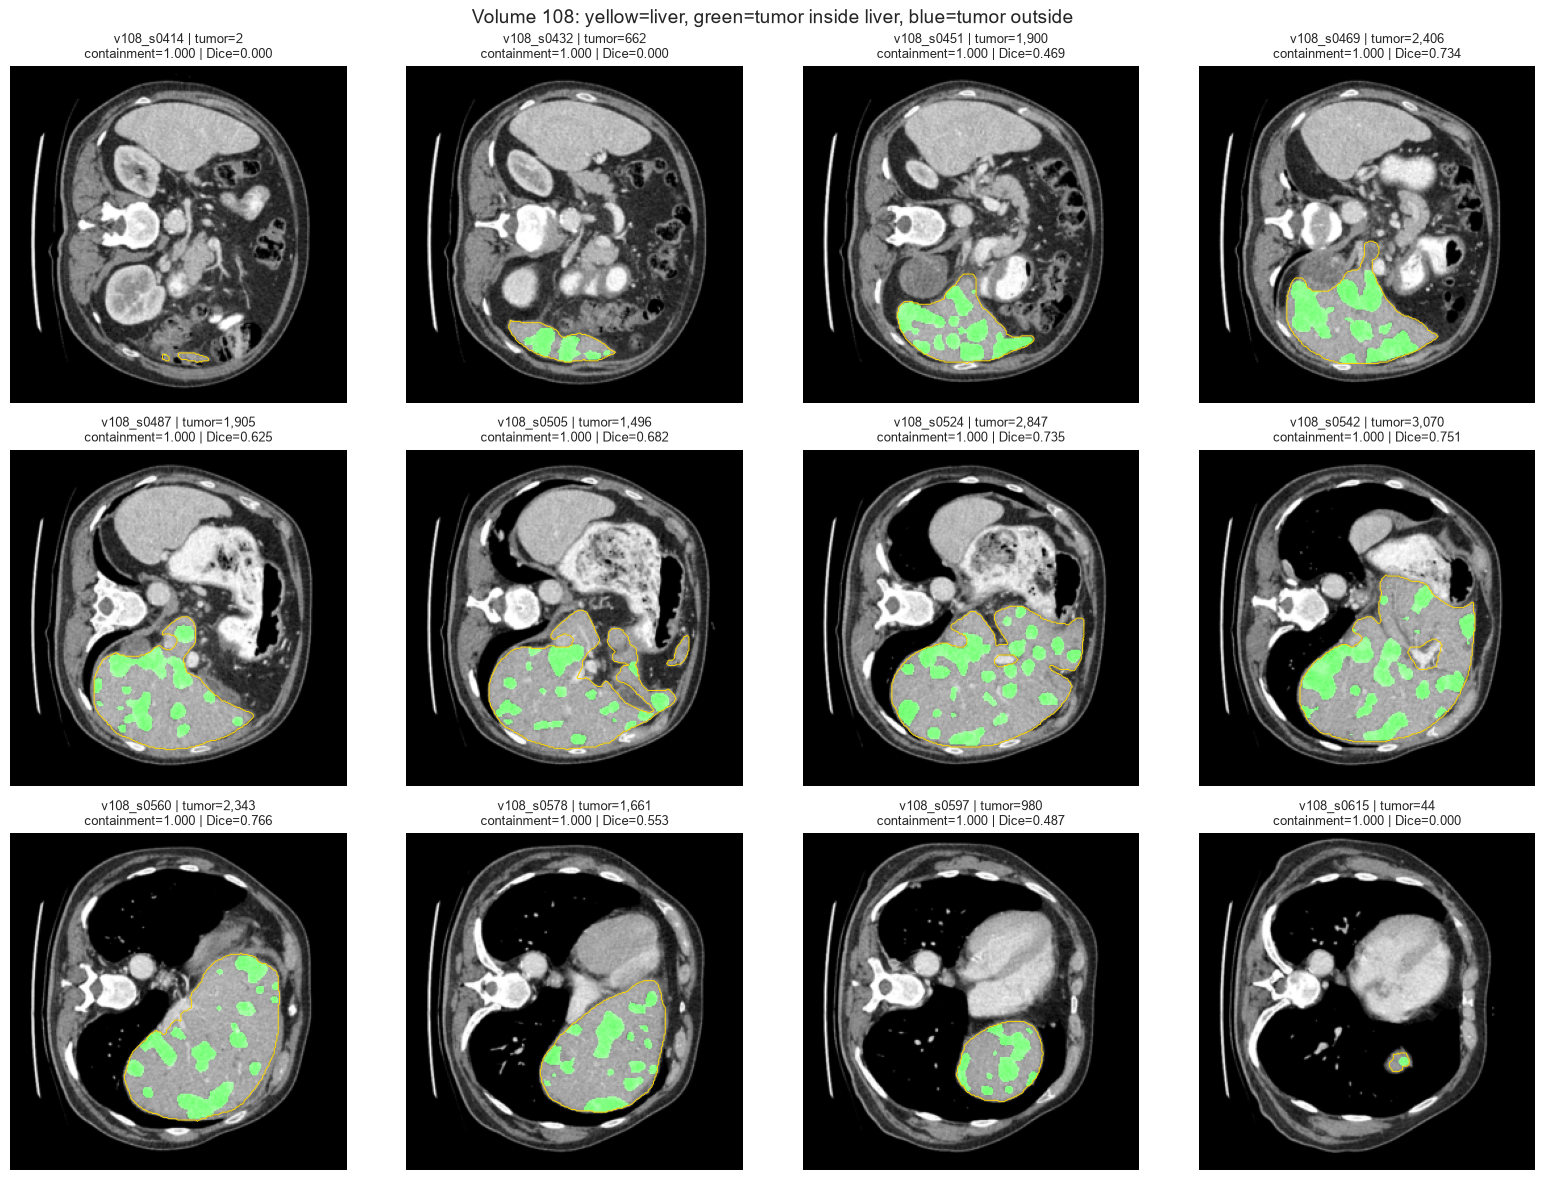

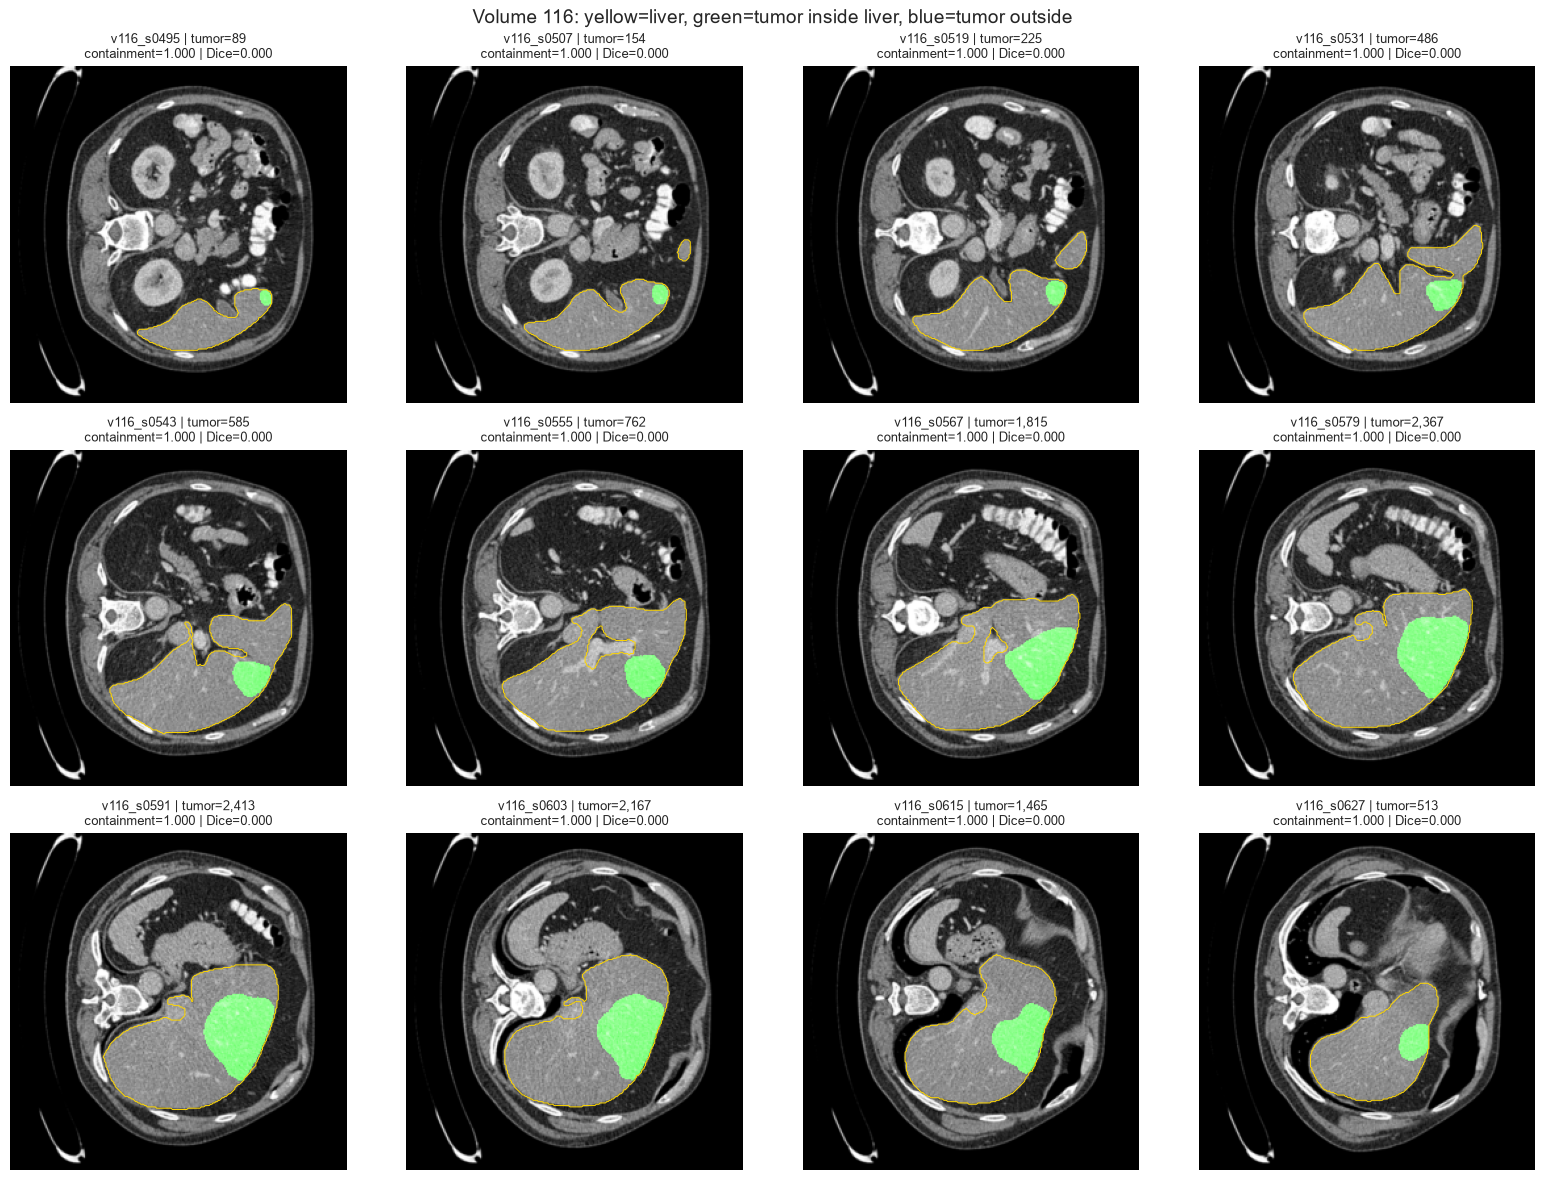

,contact_sheet
0,D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\P...
1,D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\P...
2,D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\P...
3,D:\DATA SCIENCE AND ANALYTICS\PROJECTS\Liver\P...


In [7]:
def select_longitudinal_rows(frame: pd.DataFrame, count: int) -> pd.DataFrame:
    ordered = frame.sort_values("slice_index")
    if len(ordered) <= count:
        return ordered
    positions = np.linspace(0, len(ordered) - 1, count).round().astype(int)
    return ordered.iloc[np.unique(positions)]


def render_contact_sheet(volume_id: int, count: int = 12):
    rows = manifest.loc[
        manifest["volume_id"].eq(volume_id) & manifest["tumor_pixels"].gt(0)
    ].copy()
    selected = select_longitudinal_rows(rows, count)
    columns = 4
    rows_count = math.ceil(len(selected) / columns)
    fig, axes = plt.subplots(rows_count, columns, figsize=(16, 4 * rows_count))
    axes = np.atleast_1d(axes).ravel()
    for axis, row in zip(axes, selected.itertuples(index=False)):
        with Image.open(resolve_path(row.image_path)) as handle:
            image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
        organ = load_binary(resolve_path(row.organ_mask_path))
        tumor = load_binary(resolve_path(row.tumor_mask_path))
        inside = tumor & organ
        outside = tumor & ~organ
        rgb = np.repeat(image[..., None], 3, axis=2)
        rgb[inside, 1] = np.clip(rgb[inside, 1] + 0.55, 0, 1)
        rgb[outside, 2] = 1.0
        axis.imshow(rgb)
        if organ.any():
            axis.contour(organ, levels=[0.5], colors="#FFD700", linewidths=0.7)
        containment = int(inside.sum()) / max(int(tumor.sum()), 1)
        title = f"{row.sample_id} | tumor={int(tumor.sum()):,}\ncontainment={containment:.3f}"
        if BASELINE_PER_SLICE_PATH.is_file():
            match = baseline_rows.loc[baseline_rows["sample_id"].eq(row.sample_id)]
            if len(match):
                title += f" | Dice={float(match.iloc[0]['dice']):.3f}"
        axis.set_title(title, fontsize=9)
        axis.axis("off")
    for axis in axes[len(selected):]:
        axis.axis("off")
    fig.suptitle(
        f"Volume {volume_id}: yellow=liver, green=tumor inside liver, blue=tumor outside",
        fontsize=14,
    )
    fig.tight_layout()
    path = OUTPUT_DIR / f"volume_{volume_id:03d}_longitudinal_overlay.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


contact_sheet_paths = [render_contact_sheet(volume_id, CONTACT_SHEET_SLICES) for volume_id in FOCUS_VOLUMES]
display(pd.DataFrame({"contact_sheet": [str(path) for path in contact_sheet_paths]}))

### 7. Inspect the worst containment slices across validation

,sample_id,volume_id,slice_index,tumor_pixels,tumor_outside_liver_pixels,tumor_containment,tumor_centroid_x,tumor_centroid_y,centroid_distance
314,v108_s0535,108,535,3784,0,1.0,145.078488,161.963795,8.158736
311,v108_s0532,108,532,3669,0,1.0,144.183156,161.959662,9.407279
313,v108_s0534,108,534,3630,0,1.0,144.721488,161.817906,8.586560
312,v108_s0533,108,533,3610,0,1.0,144.272576,161.757618,9.094433
315,v108_s0536,108,536,3428,0,1.0,141.851517,164.315928,5.947803
310,v108_s0531,108,531,3422,0,1.0,142.742548,161.688486,9.984992
317,v108_s0538,108,538,3401,0,1.0,141.529256,166.533373,4.054541
316,v108_s0537,108,537,3370,0,1.0,141.679822,165.361721,4.891207
322,v108_s0543,108,543,3363,0,1.0,139.016652,168.141838,8.147096
307,v108_s0528,108,528,3358,0,1.0,140.323109,167.564026,5.691489


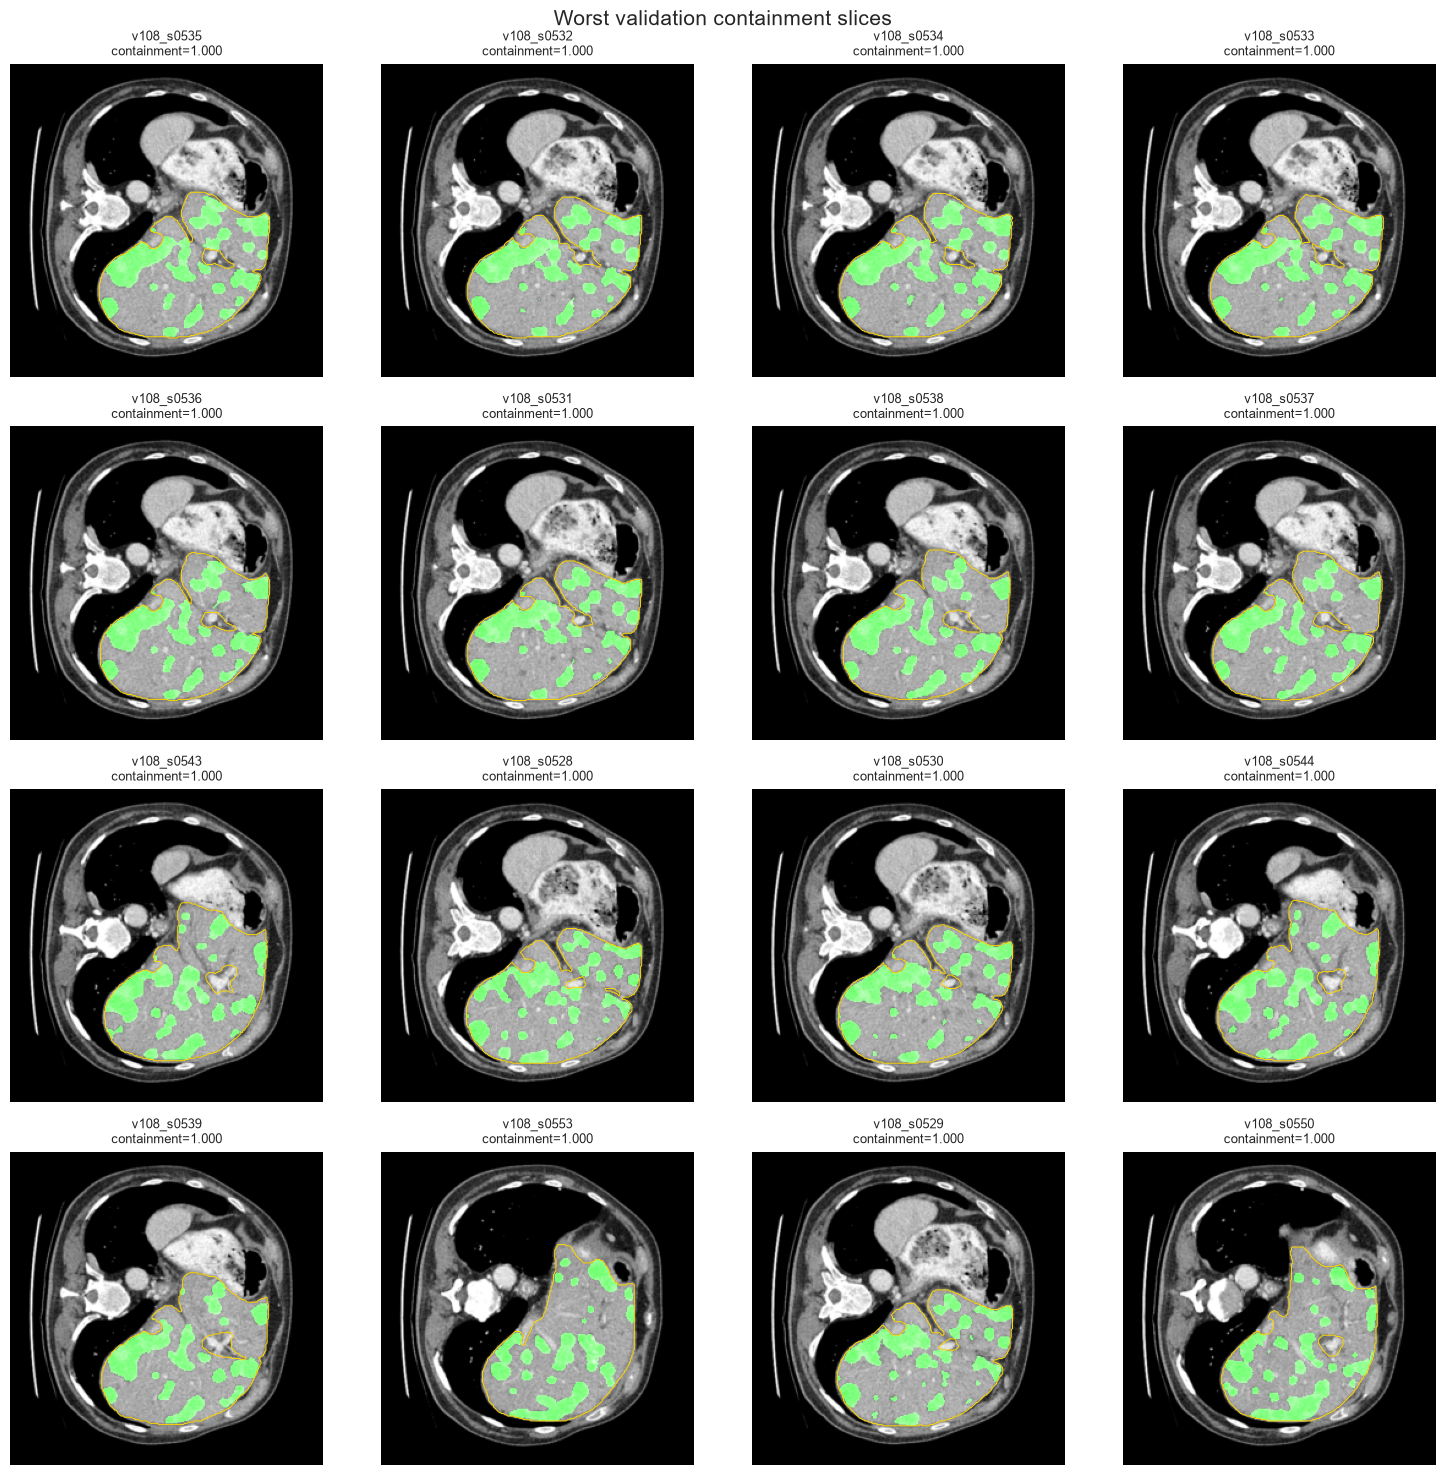

In [8]:
worst_rows = (
    validation_audit.sort_values(
        ["tumor_containment", "tumor_outside_liver_pixels", "tumor_pixels"],
        ascending=[True, False, False],
    )
    .head(16)
)
display(worst_rows[[
    "sample_id", "volume_id", "slice_index", "tumor_pixels",
    "tumor_outside_liver_pixels", "tumor_containment",
    "tumor_centroid_x", "tumor_centroid_y", "centroid_distance",
]])

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
manifest_by_id = manifest.set_index("sample_id")
for axis, audit_row in zip(axes.ravel(), worst_rows.itertuples(index=False)):
    row = manifest_by_id.loc[audit_row.sample_id]
    with Image.open(resolve_path(row.image_path)) as handle:
        image = np.asarray(handle.convert("L"), dtype=np.float32) / 255.0
    organ = load_binary(resolve_path(row.organ_mask_path))
    tumor = load_binary(resolve_path(row.tumor_mask_path))
    inside = tumor & organ
    outside = tumor & ~organ
    rgb = np.repeat(image[..., None], 3, axis=2)
    rgb[inside, 1] = 1.0
    rgb[outside, 2] = 1.0
    axis.imshow(rgb)
    axis.contour(organ, levels=[0.5], colors="#FFD700", linewidths=0.7)
    axis.set_title(
        f"{audit_row.sample_id}\ncontainment={audit_row.tumor_containment:.3f}",
        fontsize=9,
    )
    axis.axis("off")
fig.suptitle("Worst validation containment slices", fontsize=15)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "worst_validation_containment_overlays.png", dpi=160, bbox_inches="tight")
plt.show()

### 8. Audit source NIfTI metadata and processed-volume consistency

In [9]:
try:
    import nibabel as nib
except ImportError:
    nib = None

source_metadata_records = []
validation_manifest = manifest.loc[manifest["split"].eq("val")]
for volume_id, group in validation_manifest.groupby("volume_id"):
    first = group.iloc[0]
    volume_path = Path(first["source_volume_path"])
    segmentation_path = Path(first["source_segmentation_path"])
    record = {
        "volume_id": int(volume_id),
        "processed_slices": int(len(group)),
        "source_volume_exists": volume_path.is_file(),
        "source_segmentation_exists": segmentation_path.is_file(),
        "source_volume_path": str(volume_path),
        "source_segmentation_path": str(segmentation_path),
    }
    if nib is not None and volume_path.is_file() and segmentation_path.is_file():
        volume_image = nib.load(str(volume_path))
        segmentation_image = nib.load(str(segmentation_path))
        record.update({
            "source_volume_shape": str(volume_image.shape),
            "source_segmentation_shape": str(segmentation_image.shape),
            "source_shapes_match": volume_image.shape == segmentation_image.shape,
            "processed_slice_count_matches_source": len(group) == volume_image.shape[2],
            "volume_axcodes": str(nib.aff2axcodes(volume_image.affine)),
            "segmentation_axcodes": str(nib.aff2axcodes(segmentation_image.affine)),
            "axcodes_match": nib.aff2axcodes(volume_image.affine) == nib.aff2axcodes(segmentation_image.affine),
            "affines_close": bool(np.allclose(volume_image.affine, segmentation_image.affine)),
        })
    source_metadata_records.append(record)

source_metadata = pd.DataFrame(source_metadata_records)
source_metadata.to_csv(OUTPUT_DIR / "validation_source_metadata_audit.csv", index=False)
display(source_metadata)

,volume_id,processed_slices,source_volume_exists,source_segmentation_exists,source_volume_path,source_segmentation_path,source_volume_shape,source_segmentation_shape,source_shapes_match,processed_slice_count_matches_source,volume_axcodes,segmentation_axcodes,axcodes_match,affines_close
0,104,781,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 781)","(512, 512, 781)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
1,105,986,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 986)","(512, 512, 986)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
2,106,771,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 771)","(512, 512, 771)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
3,107,771,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 771)","(512, 512, 771)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
4,108,856,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 856)","(512, 512, 856)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
5,109,756,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 756)","(512, 512, 756)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
6,110,816,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 816)","(512, 512, 816)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
7,111,761,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 761)","(512, 512, 761)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
8,112,751,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 751)","(512, 512, 751)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False
9,113,836,True,True,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,D:\DATA SCIENCE AND ANALYTICS\Dataset\Liver\01...,"(512, 512, 836)","(512, 512, 836)",True,True,"('R', 'A', 'S')","('L', 'P', 'S')",False,False


## Takeaways

### 9. Produce the final forensic decision

In [10]:
path_and_shape_pass = True
volume_containment_pass = bool(
    volume_geometry["volume_containment"].ge(VOLUME_CONTAINMENT_GATE).all()
)
slice_containment_pass = bool(
    validation_audit["tumor_containment"].ge(SLICE_CONTAINMENT_GATE).all()
)
source_metadata_pass = True
if "source_shapes_match" in source_metadata:
    source_metadata_pass = bool(
        source_metadata[
            ["source_volume_exists", "source_segmentation_exists",
             "source_shapes_match", "processed_slice_count_matches_source",
             "axcodes_match", "affines_close"]
        ].fillna(False).all().all()
    )

automated_pass = all([
    path_and_shape_pass,
    volume_containment_pass,
    slice_containment_pass,
    source_metadata_pass,
])

forensic_result = {
    "dataset_build": DATASET_ROOT.name,
    "manifest_sha256": observed_manifest_hash,
    "validation_tumor_positive_slices_audited": int(len(validation_audit)),
    "training_reference_slices_audited": int(len(training_audit)),
    "minimum_volume_containment": float(volume_geometry["volume_containment"].min()),
    "minimum_slice_containment": float(validation_audit["tumor_containment"].min()),
    "slices_below_99pct_containment": int((validation_audit["tumor_containment"] < 0.99).sum()),
    "source_metadata_pass": source_metadata_pass,
    "automated_geometry_gate_pass": automated_pass,
    "manual_contact_sheet_review_required": True,
    "test_images_accessed": False,
    "decision": (
        "AUTOMATED PASS — manually review focus-volume contact sheets. If anatomy is credible, "
        "start a fresh 20–30 epoch baseline with patient-level metrics."
        if automated_pass else
        "FAIL — do not continue model training. Identify and correct the failing volumes, "
        "rebuild the manifest, and repeat loader/overfit gates."
    ),
}

(OUTPUT_DIR / "validation_forensic_gate_result.json").write_text(
    json.dumps(forensic_result, indent=2), encoding="utf-8"
)
display(pd.DataFrame([forensic_result]).T.rename(columns={0: "result"}))
print(forensic_result["decision"])

,result
dataset_build,build_corrected_20260713_214847_v2
manifest_sha256,575a6fc391d63dc9bbbbb3317efe4d0f65edd57457ae63...
validation_tumor_positive_slices_audited,1042
training_reference_slices_audited,1200
minimum_volume_containment,1.0
minimum_slice_containment,1.0
slices_below_99pct_containment,0
source_metadata_pass,False
automated_geometry_gate_pass,False
manual_contact_sheet_review_required,True


FAIL — do not continue model training. Identify and correct the failing volumes, rebuild the manifest, and repeat loader/overfit gates.


### Manual review checklist

For each generated focus-volume contact sheet:

1. Confirm the yellow liver contour follows the liver throughout the volume.
2. Confirm green tumor regions are anatomically inside the liver.
3. Confirm no systematic 180° mismatch exists between image and masks.
4. Compare adjacent slices for plausible lesion continuity.
5. Examine volume 116 closely: the baseline missed its large annotations.
6. Examine false-positive examples from the prior smoke-test montage.

Record approval only when both the automated geometry gate and anatomical review
pass. Do not inspect or unlock the held-out test split during this process.